In [2]:
import sys
import site

print("Python:", sys.executable)
print("Site-packages:")
for p in site.getsitepackages():
    print(" -", p)

Python: /pscratch/sd/h/hugon/my_env/bin/python
Site-packages:
 - /pscratch/sd/h/hugon/my_env/lib/python3.13/site-packages


In [2]:
%ls
%cd /global/homes/h/hugon/home/acm
%ls

acm/
acm.egg-info/
astra_methodB_sub10/
astra_output_3.npz
astra_outputs_sub10/
astra_outputs_sub4/
build/
corr_outputs/
corr_outputs_astra_outputs_sub1_methodA_fast/
dataset_fcn_nano_3_jax10_1.npz
dataset_fcn_nano_test.npz
docs/
hod_class_2.fits.gz
hod_class_test.fits.gz
hod_pairs_2.fits.gz
hod_pairs_test.fits.gz
hod_probability_2.fits.gz
hod_probability_test.fits.gz
Makefile
multipoles_methodB/
nb/
pyproject.toml
random_positions_2.npy
random_positions.npy
README.md
r_values.pkl
scripts/
setup.py
slurm-49458966.out
slurm-49464700.out
slurm-49465580.out
slurm-49468095.out
slurm-49566698.out
slurm-49567310.out
slurm_dataset_50494516.out
slurm_dataset_50516908.out
slurm_dataset_simple_50602468.out
slurm_dataset_simple_jax_51512060.out
slurm_methodA_49681245.out
slurm_methodA_49705262.out
slurm_methodA_49835567.out
slurm_methodA_49845760.out
slurm_methodA_49993471.out
slurm_methodA_50494453.out
slurm_methodA_50599271_0.out
slurm_methodA_50599271_14.out
slurm_methodB_49681254.out
slurm_me

In [3]:
from pathlib import Path
import glob
import fitsio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import acm.estimators.galaxy_clustering.astra_split as astra_split

def get_hod_fns(cosmo=1, phase=0, redshift=0.5, seed=0):
    """
    Get the list of HOD file names for a given cosmology,
    phase, and redshift.
    """
    base_dir = '/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/'
    hod_dir = Path(base_dir) / f'c{cosmo:03}_ph{phase:03}/seed{seed}/'
    hod_fns = glob.glob(str(Path(hod_dir) / f'hod*.fits'))
    return sorted(hod_fns)

def get_hod_positions(filename, los='z'):
    """Get redshift-space positions from a HOD file."""
    hod, header = fitsio.read(filename, header=True)
    qpar, qperp = header['Q_PAR'], header['Q_PERP']
    if los == 'x':
        pos = np.c_[hod['X_RSD'], hod['Y_PERP'], hod['Z_PERP']]
        boxsize = np.array([2000/qpar, 2000/qperp, 2000/qperp])
    elif los == 'y':
        pos = np.c_[hod['X_PERP'], hod['Y_RSD'], hod['Z_PERP']]
        boxsize = np.array([2000/qperp, 2000/qpar, 2000/qperp])
    elif los == 'z':
        pos = np.c_[hod['X_PERP'], hod['Y_PERP'], hod['Z_RSD']]
        boxsize = np.array([2000/qperp, 2000/qperp, 2000/qpar])
    return pos, boxsize

def get_box_args(boxsize, cellsize):
    meshsize = (boxsize / cellsize).astype(int)
    return dict(boxsize=boxsize, boxcenter=0.0, meshsize=meshsize)

# load galaxy catalog for testing
hod_fn = get_hod_fns(cosmo=0, phase=0, redshift=0.5)[0]
positions, boxsize = get_hod_positions(hod_fn, los='z')
box_args=get_box_args(boxsize, cellsize=10)

In [7]:
print("boxsize:", boxsize)
print("positions shape:", positions.shape)
print('min and max positions:', positions.min(axis=0), positions.max(axis=0))

boxsize: [2000. 2000. 2000.]
positions shape: (4000000, 3)
min and max positions: [-999.99926758 -999.99975586 -999.99981786] [999.99975586 999.99926758 999.99998799]


N galaxies: 4639546
Boxsize: [2077.31965325 2077.31965325 2150.29923324]
min: [-1038.65982662 -1038.65906589 -1075.14961474] max: [1038.65982662 1038.65982662 1075.1495549 ]


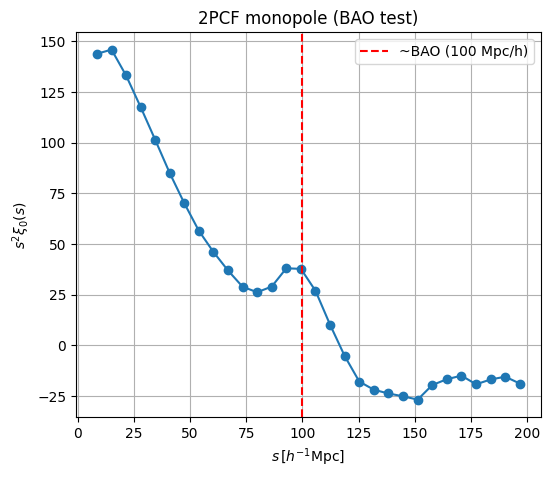

In [10]:
from pycorr import TwoPointCorrelationFunction

# -----------------------------
# Paramètres 2PCF
# -----------------------------
N_BINS = 30
R_MIN = 5
R_MAX = 200

s_edges = np.linspace(R_MIN, R_MAX, N_BINS + 1)
mu_edges = np.linspace(-1, 1, 121)
edges = (s_edges, mu_edges)

# -----------------------------
# (optionnel) subsample léger
# -----------------------------
SUB = 1  # mets 1 pour aucun subsampling

if SUB > 1:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(positions), size=len(positions)//SUB, replace=False)
    pos = positions[idx]
else:
    pos = positions

print("N galaxies:", len(pos))
print("Boxsize:", boxsize)
print("min:", pos.min(axis=0), "max:", pos.max(axis=0))

# -----------------------------
# 2PCF
# -----------------------------
result = TwoPointCorrelationFunction(
    data_positions1=pos,
    mode='smu',
    edges=edges,
    boxsize=boxsize,
    los='z',
    nthreads=8,
    position_type='pos',
)

s, multipoles = result(ells=(0,), return_sep=True)
xi0 = multipoles[0]

# -----------------------------
# Plot BAO (IMPORTANT)
# -----------------------------
plt.figure(figsize=(6,5))
plt.plot(s, s**2 * xi0, marker='o')
plt.axvline(100, color='red', linestyle='--', label='~BAO (100 Mpc/h)')

plt.xlabel(r"$s \, [h^{-1} \mathrm{Mpc}]$")
plt.ylabel(r"$s^2 \xi_0(s)$")
plt.title("2PCF monopole (BAO test)")
plt.legend()
plt.grid()

plt.show()

In [4]:

import argparse
import sys
from pathlib import Path
import time
import matplotlib.pyplot as plt

import os


# attention nthreads, increase max--files and careful with memory

from pycorr import TwoPointCorrelationFunction


import numpy as np
import pandas as pd
import fitsio
import yaml
from scipy.spatial import cKDTree
from itertools import product
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

# Ensure local package imports work when running the script from inside acm/acm/

%cd /global/homes/h/hugon/home/acm/
import acm.estimators.galaxy_clustering.astra_split as astra_split
from acm.estimators.galaxy_clustering.density_split import DensitySplit
import pandas as pd 
from pathlib import Path
import numpy as np
import fitsio

COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

FEATURE_COLS = [
    "omega_b","omega_cdm","h","A_s","n_s","alpha_s",
    "N_ur","N_ncdm","omega_ncdm","w0_fld","wa_fld",
    "sigma8_m","sigma8_cb"
]

BASE_DIR = Path('/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/')


SUBSAMPLE_FACTOR = 10
n_threads = 1
max_files=1  
n_workers=1

N_BINS = 25
R_MIN = 5
R_MAX = 200

SEED = 42
rng = np.random.default_rng(SEED)

CHECKPOINT_FILE = f"dataset_checkpoint_3_jax{SUBSAMPLE_FACTOR}_{max_files}.npz"
OUTPUT_FILE = f"dataset_fcn_nano_3_jax{SUBSAMPLE_FACTOR}_{max_files}.npz"

def get_all_hod_files(base_dir):
    all_files = []

    for cosmo_phase_dir in base_dir.glob("c*_ph*"):
        cosmo_id = int(cosmo_phase_dir.name.split("_")[0][1:])

        for seed_dir in cosmo_phase_dir.glob("seed*"):
            for f in seed_dir.glob("hod*.fits"):
                all_files.append((f, cosmo_id))

    return all_files


all_files = get_all_hod_files(BASE_DIR)

print("Total files found:", len(all_files))


cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()
cosmo_df["cosmo_id"] = cosmo_df["root"].str.extract(r"cosm(\d+)").astype(int)
cosmo_df = cosmo_df.set_index("cosmo_id")

hod_file,_ = all_files[0]
positions, boxsize = get_hod_positions(hod_file, los='z')
n_data = len(positions) // SUBSAMPLE_FACTOR
idx = rng.choice(len(positions), size=n_data, replace=False)
positions_sub=np.asarray(positions[idx], dtype=np.float32)  # pour jax

/global/u1/h/hugon/home/acm
Total files found: 42500


In [5]:
print('min and max positions:', positions_sub.min(axis=0), positions_sub.max(axis=0))

min and max positions: [-1038.6586 -1038.6556 -1075.1473] [1038.6567 1038.6349 1075.1414]


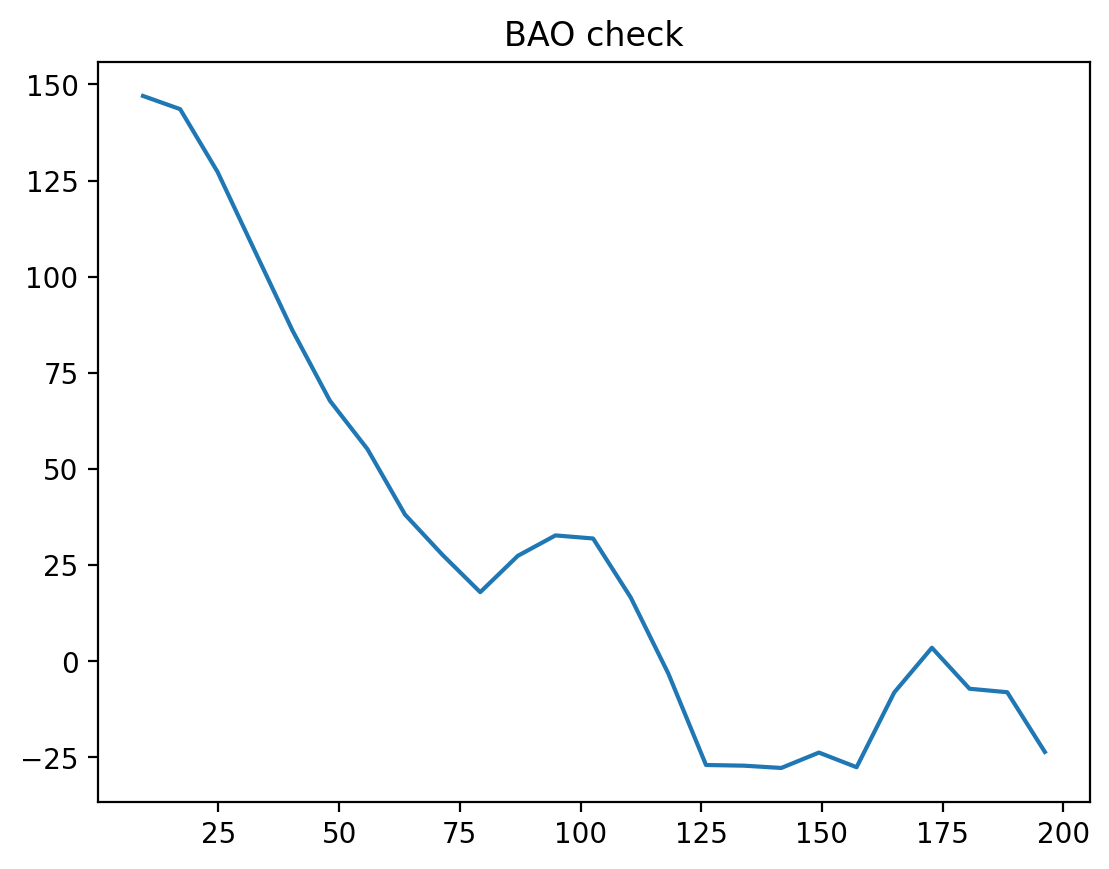

In [6]:
from pycorr import TwoPointCorrelationFunction
import matplotlib.pyplot as plt

edges = (np.linspace(R_MIN, R_MAX, N_BINS + 1), np.linspace(-1, 1, 121))

result_2pcf = TwoPointCorrelationFunction(
        data_positions1=positions_sub,
        mode='smu',
        edges=edges,
        boxsize=boxsize,
        los='z',
        nthreads=n_threads,
        position_type='pos',
    )

s, multipoles = result_2pcf(ells=(0,), return_sep=True)

plt.plot(s, s**2 * multipoles[0])
plt.title("BAO check")
plt.show()

 Check de tout le code simple jax

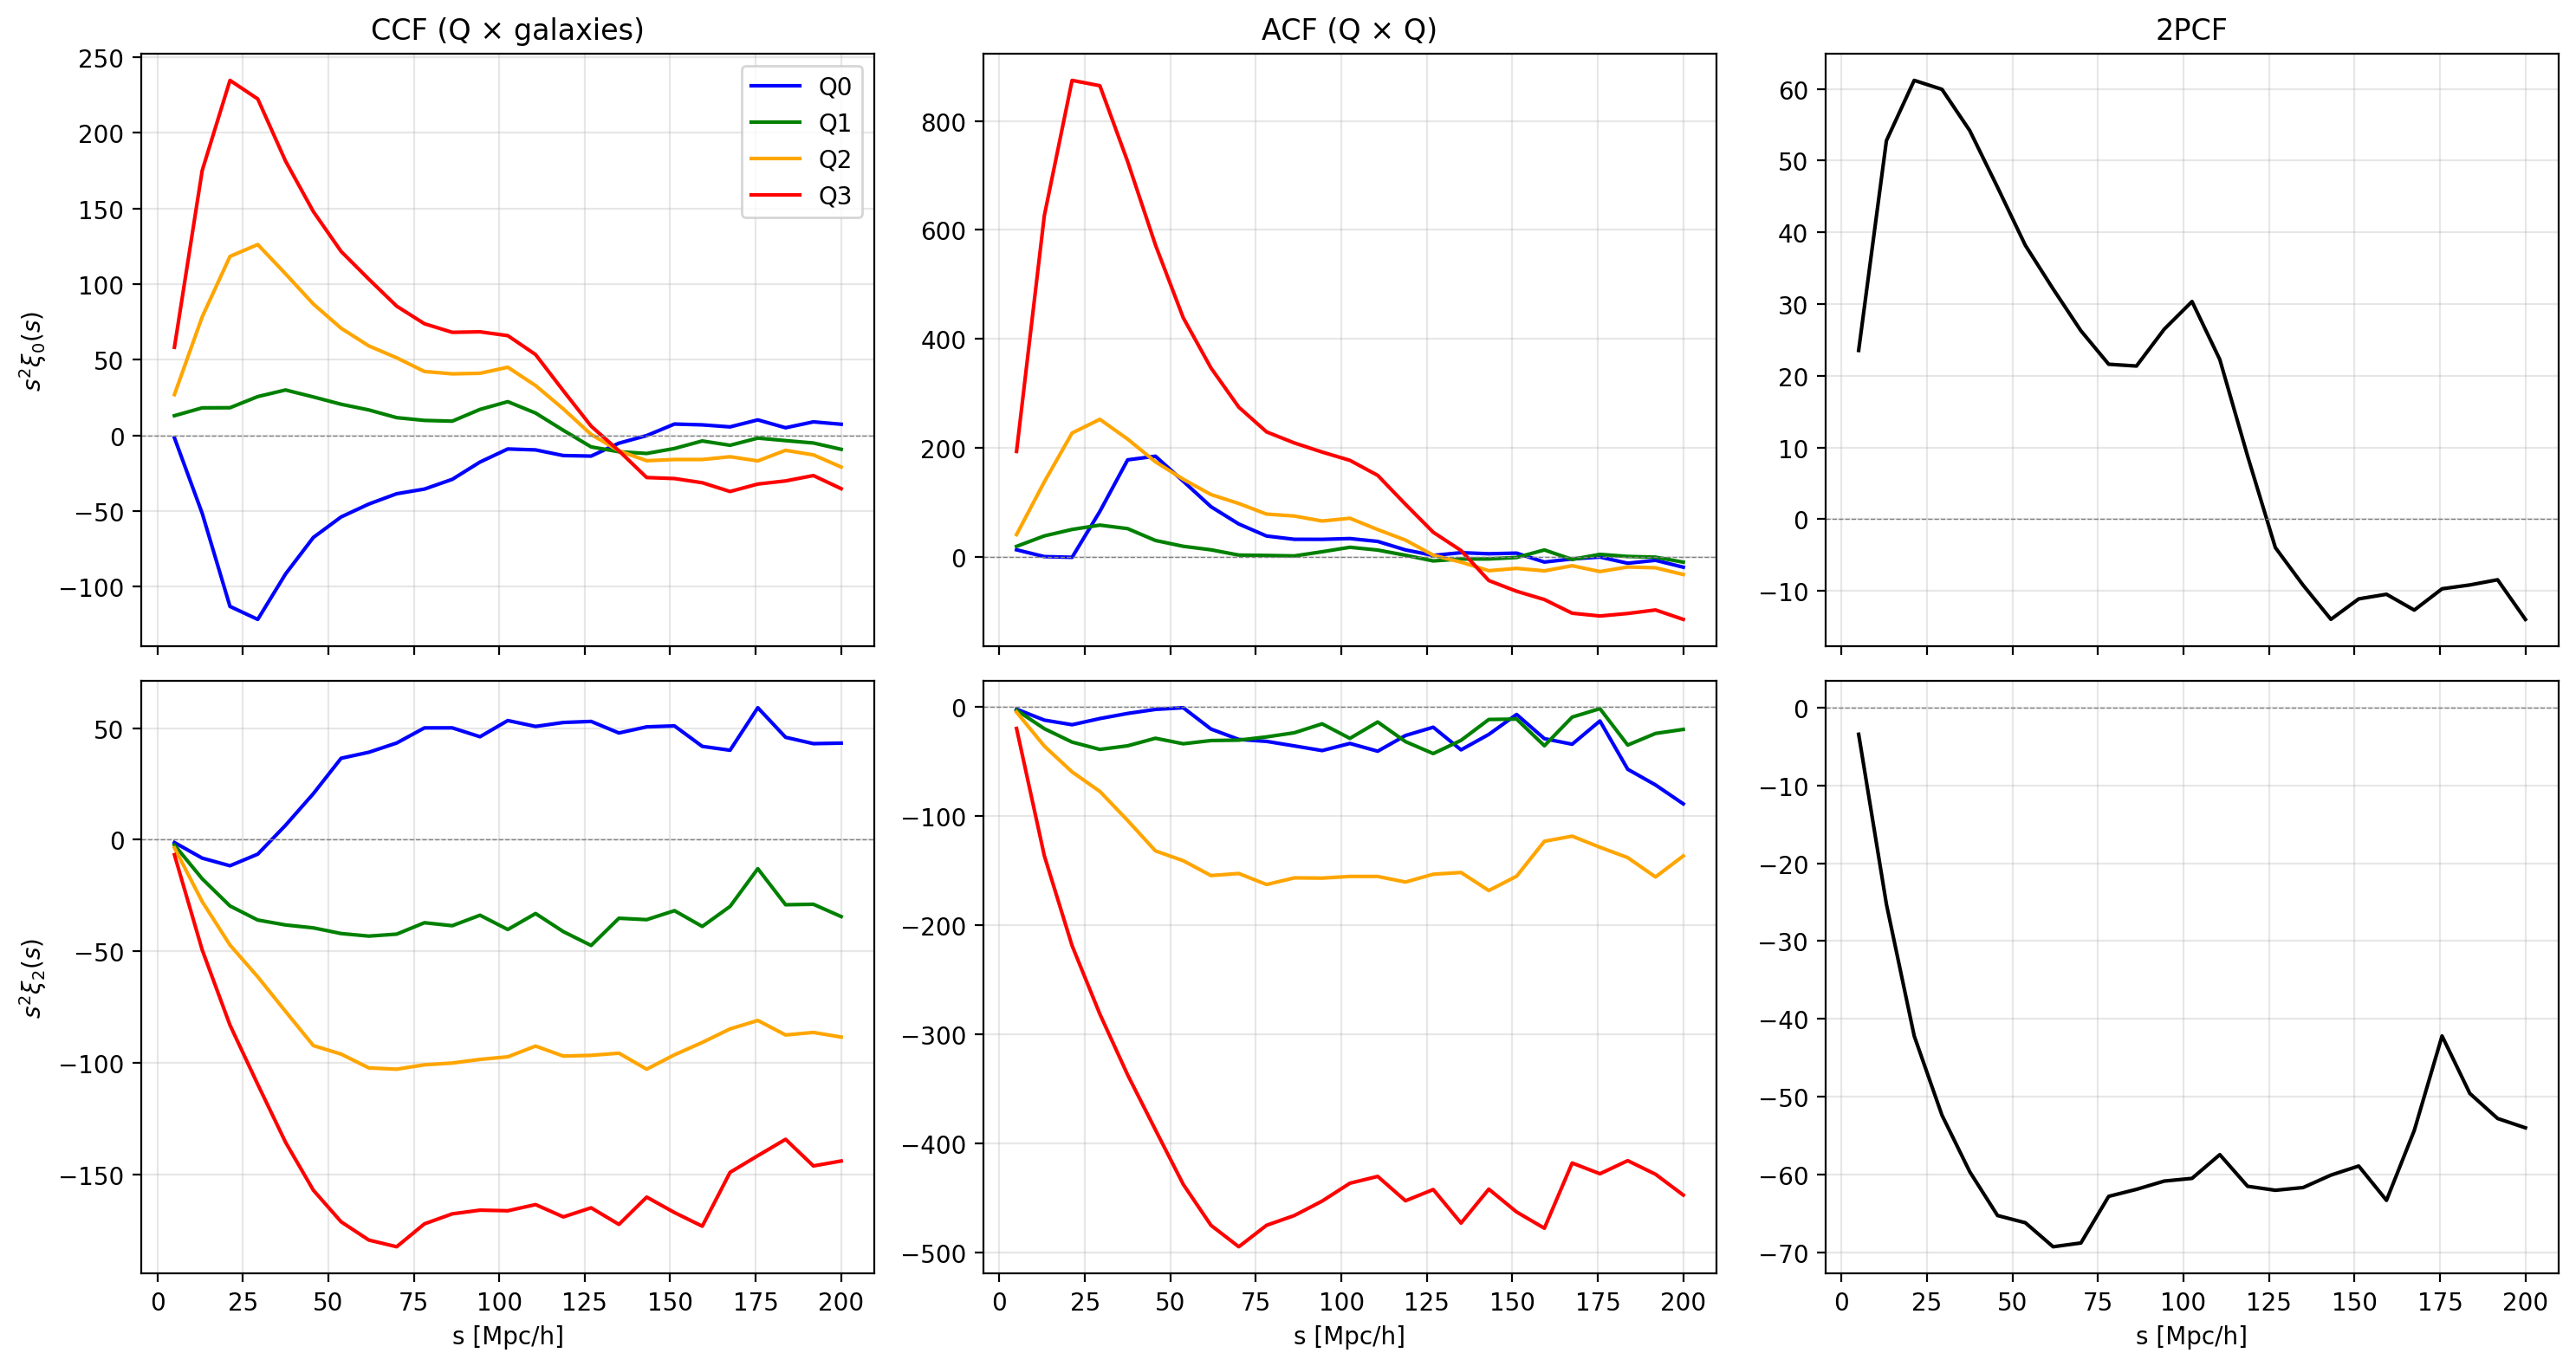

In [8]:
dataset_path = "/global/homes/h/hugon/home/dataset_fcn_nano_3_jax7_10.npz"

data = np.load(dataset_path, allow_pickle=True)
X = data["X"]
Y = data["Y"]

N_BINS = 25
R_MIN = 5
R_MAX = 200

s = np.linspace(R_MIN, R_MAX, N_BINS)
colors = ["blue", "green", "orange", "red"]

mean_vec = Y.mean(axis=0)
vec = mean_vec

blocks = []
for i in range(9):
    start = i * 2 * N_BINS
    mid   = start + N_BINS
    end   = start + 2 * N_BINS
    xi0 = vec[start:mid]
    xi2 = vec[mid:end]
    blocks.append((xi0, xi2, start, mid, end))

ccf_blocks = blocks[:4]
acf_blocks = blocks[4:8]
tpcf_block = blocks[8]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
titles = ["CCF (Q × galaxies)", "ACF (Q × Q)", "2PCF"]
ylabels = [r"$s^2 \xi_0(s)$", r"$s^2 \xi_2(s)$"]

for col in range(3):
    for row in range(2):
        ax = axes[row, col]

        if col == 0:
            blocks_plot = ccf_blocks
        elif col == 1:
            blocks_plot = acf_blocks
        else:
            blocks_plot = [tpcf_block]

        for i, (xi0, xi2, start, mid, end) in enumerate(blocks_plot):
            y_raw = xi0 if row == 0 else xi2
            y = s**2 * y_raw  

            if col < 2:
                ax.plot(s, y, color=colors[i], label=f"Q{i}")
            else:
                ax.plot(s, y, color="black")

        if row == 0:
            ax.set_title(titles[col])
        if col == 0:
            ax.set_ylabel(ylabels[row])
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        ax.grid(alpha=0.3)

axes[0, 0].legend()
for ax in axes[-1]:
    ax.set_xlabel("s [Mpc/h]")

plt.tight_layout()
plt.show()

